# Testing trajectories to make realistic simulations

In [1]:
import matplotlib.pyplot as plt
import numpy as np



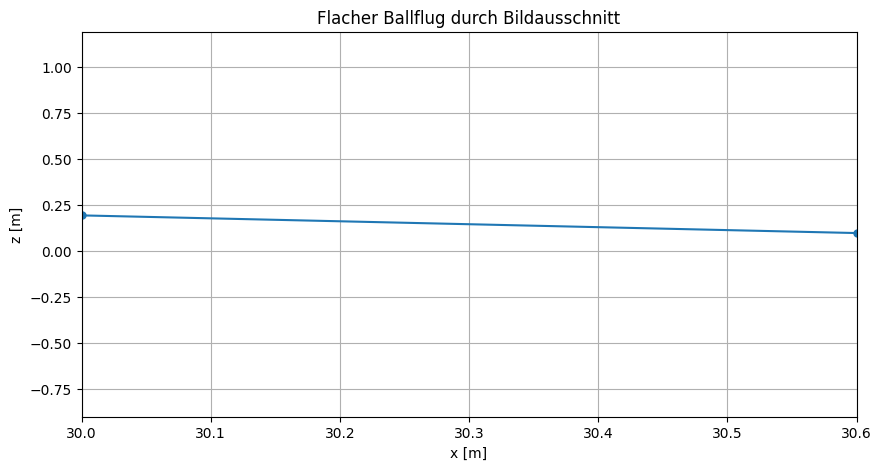

In [3]:

# Parameter
g = 9.81            # Erdbeschleunigung [m/s^2]
dt = 0.02           # Zeitschritt [s]
timesteps = 500     # Anzahl der Schritte

# Startbedingungen
pos = np.array([0.0, 0.0, 0.0])  # Start bei (x,y,z)
v0 = np.array([30.0, 10.0, 5.0])  # Startgeschwindigkeit in m/s (x, y, z)

# Arrays zur Speicherung
positions = [pos.copy()]

velocity = v0.copy()

for t in range(timesteps):
    # Update Position
    pos = pos + velocity * dt
    # Update Geschwindigkeit (nur z wird von Schwerkraft beeinflusst)
    velocity[2] -= g * dt
    
    # Falls der Ball den Boden (z=0) erreicht, stoppen
    if pos[2] <= 0 and t > 0:
        break
    
    positions.append(pos.copy())

positions = np.array(positions)

# Wir wählen nur einen Ausschnitt des Flugs (z.B. mittleres Stück)
start_idx = 50
end_idx = start_idx + 120
positions_cut = positions[start_idx:end_idx]

# 2D-Projektion: x und z Ebene (Seitenansicht)
plt.figure(figsize=(10, 5))
plt.plot(positions_cut[:,0], positions_cut[:,2], 'o-', markersize=5)

plt.title("Flacher Ballflug durch Bildausschnitt")
plt.xlabel("x [m]")
plt.ylabel("z [m]")
plt.grid(True)

# Bildausschnitt so setzen, dass er genau das mittlere Stück zeigt
plt.xlim(positions_cut[0,0], positions_cut[-1,0])
plt.ylim(positions_cut[:,2].min() - 1, positions_cut[:,2].max() + 1)

# plt.savefig("ball_flugkurve_auschnitt.png", dpi=150)
plt.show()